# 인공 신경망

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/07-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [1]:
import warnings
warnings.filterwarnings('ignore') # 모든 경고 끄기

import tensorflow as tf
import keras

print("GPU 확인:", tf.config.list_physical_devices('GPU'))

GPU 확인: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# import warnings
# import os

# # 1. 파이썬 수준의 경고 숨기기
# warnings.filterwarnings('ignore', category=UserWarning)
# # 특히 requests 관련 경고를 타겟팅해서 숨깁니다.
# warnings.filterwarnings('ignore', message='.*urllib3.*')

# # 2. 텐서플로 내부 시스템 메시지 숨기기 (0:모두출력, 1:인포제외, 2:경고제외, 3:에러만)
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

## 패션 MNIST

In [4]:
import keras

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

In [5]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [6]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [12]:
# %pip install matplotlib

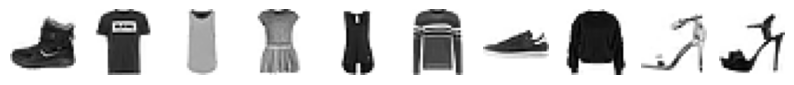

In [14]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    # 그래프 눈금을 지우기위해 off
    axs[i].axis('off') 
plt.show()

In [15]:
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


In [16]:
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


## 로지스틱 회귀로 패션 아이템 분류하기

In [17]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

In [18]:
print(train_scaled.shape)

(60000, 784)


In [23]:
# %pip install scikit-learn

In [22]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

0.84955


## 인공신경망

### 텐서플로와 케라스

In [12]:
import tensorflow as tf

In [13]:
import keras

In [26]:
keras.config.backend()

'tensorflow'

In [25]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # 또는 "jax"

## 인공신경망으로 모델 만들기

In [27]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [28]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [29]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [34]:
# 1. 입력 모양 정의 (예: 패션 MNIST는 28x28를 1줄로 편 784개)
inputs = keras.Input(shape=(784,))

# 2. 레이어 정의 (예: 10개 뉴런을 가진 출력층)
dense = keras.layers.Dense(10, activation='softmax')

# 3. 모델 조립
# Sequential 음악 테이프 처럼 순차적으로 출력
model = keras.Sequential([inputs, dense])

# 4. 확인 (이걸 실행했을 때 표가 나오면 완벽 성공!)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## 인공신경망으로 패션 아이템 분류하기

In [35]:
# sparse 희소하다
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [36]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [37]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5


2026-03-22 19:22:48.825179: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-22 19:22:48.826000: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7925 - loss: 0.6082
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8378 - loss: 0.4744
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8467 - loss: 0.4501
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8513 - loss: 0.4372
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8536 - loss: 0.4290


In [38]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8465 - loss: 0.4437


[0.44374674558639526, 0.8464999794960022]